In [51]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt



pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [52]:
df=pd.read_csv('Blood_Glucose.csv')
df.head()

,Age,Gender,Blood Glucose Reading,Diastolic Blood Pressure,Diastolic Blood Pressure Level,Systolic Blood Pressure,Heart Rate,Body Temperature,SPO2,Sweating (Y/N),Shivering (Y/N),Diabetic/NonDiabetic (D/N)
0,9.0,M,79.0,73.0,High,118.0,98.0,98.300707,99.0,0.0,0.0,N
1,9.0,F,80.0,73.0,High,119.0,102.0,98.300707,94.0,1.0,0.0,N
2,9.0,M,70.0,76.0,High,110.0,81.0,98.300707,98.0,1.0,0.0,N
3,9.0,F,NaN,78.0,High,115.0,96.0,98.300707,NaN,NaN,NaN,N
4,66.0,M,100.0,96.0,High,144.0,92.0,97.807052,98.0,0.0,0.0,N


In [53]:
df.shape

(16969, 12)

In [54]:
df.isnull().sum()
df.duplicated().sum()

np.int64(146)

In [55]:
df.columns

Index(['Age', 'Gender', 'Blood Glucose Reading', 'Diastolic Blood Pressure',
       'Diastolic Blood Pressure Level', 'Systolic Blood Pressure',
       'Heart Rate', 'Body Temperature', 'SPO2', 'Sweating  (Y/N)',
       'Shivering (Y/N)', 'Diabetic/NonDiabetic (D/N)'],
      dtype='object')

In [56]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16969 entries, 0 to 16968
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             16969 non-null  float64
 1   Gender                          16877 non-null  object 
 2   Blood Glucose Reading           16121 non-null  float64
 3   Diastolic Blood Pressure        16950 non-null  float64
 4   Diastolic Blood Pressure Level  16950 non-null  object 
 5   Systolic Blood Pressure         16969 non-null  float64
 6   Heart Rate                      16969 non-null  float64
 7   Body Temperature                16735 non-null  float64
 8   SPO2                            16121 non-null  float64
 9   Sweating  (Y/N)                 16121 non-null  float64
 10  Shivering (Y/N)                 16121 non-null  float64
 11  Diabetic/NonDiabetic (D/N)      16969 non-null  object 
dtypes: float64(9), object(3)
memory 

In [57]:
df.describe()

,Age,Blood Glucose Reading,Diastolic Blood Pressure,Systolic Blood Pressure,Heart Rate,Body Temperature,SPO2,Sweating (Y/N),Shivering (Y/N)
count,16969.000000,16121.000000,16950.000000,16969.000000,16969.000000,16735.000000,16121.000000,16121.000000,16121.000000
mean,30.982209,95.719219,77.172537,118.183029,91.505045,97.359325,97.380645,0.121493,0.145481
std,29.736598,49.947465,8.414652,8.947304,12.084934,0.814258,0.986455,0.379650,0.409722
min,-122.524773,-162.066433,33.724424,71.984987,29.065509,96.000132,92.287436,-1.838546,-1.970002
25%,9.000000,68.000000,71.000000,113.000000,84.000000,96.674465,97.000000,0.000000,0.000000
50%,14.000000,83.000000,76.000000,118.000000,89.000000,97.331641,98.000000,0.000000,0.000000
75%,55.000000,108.000000,83.000000,124.000000,95.000000,97.953929,98.000000,0.000000,0.000000
max,184.502497,353.498975,120.622562,164.389343,153.982873,98.999792,102.476288,2.081459,2.260927


In [58]:
# Get all duplicate-related rows: original + duplicate copies
dup_cols = df.columns.tolist()

duplicates_all = df[df.duplicated(keep=False)].copy()

# Create duplicate group number
duplicates_all['Duplicate_Group'] = duplicates_all.groupby(
    dup_cols,
    dropna=False
).ngroup() + 1

# Create copy number inside each duplicate group
duplicates_all['Copy_Number'] = duplicates_all.groupby('Duplicate_Group').cumcount() + 1

# Mark first row as Original, others as Duplicate
duplicates_all['Row_Type'] = duplicates_all['Copy_Number'].apply(
    lambda x: 'Original' if x == 1 else 'Duplicate'
)

# Show original index also
duplicates_all = duplicates_all.reset_index(names='Original_Index')

# Sort so original and duplicates come up/down together
duplicates_all = duplicates_all.sort_values(
    by=['Duplicate_Group', 'Copy_Number']
)

duplicates_all

df = df.drop_duplicates().copy()

In [59]:
cat_col=df.select_dtypes(include=['object']).columns
binary_cols = ['Sweating  (Y/N)', 'Shivering (Y/N)']
num_col=df.select_dtypes(include=['int64','float64']).columns
num_col=num_col.drop(binary_cols)
print(f'categorical_features:{cat_col}')
print(f'numerical_features:{num_col}')
print(f'binary_features:{binary_cols}')

categorical_features:Index(['Gender', 'Diastolic Blood Pressure Level',
       'Diabetic/NonDiabetic (D/N)'],
      dtype='object')
numerical_features:Index(['Age', 'Blood Glucose Reading', 'Diastolic Blood Pressure',
       'Systolic Blood Pressure', 'Heart Rate', 'Body Temperature', 'SPO2'],
      dtype='object')
binary_features:['Sweating  (Y/N)', 'Shivering (Y/N)']


In [60]:
df[num_col].describe()

,Age,Blood Glucose Reading,Diastolic Blood Pressure,Systolic Blood Pressure,Heart Rate,Body Temperature,SPO2
count,16823.000000,15985.000000,16804.000000,16823.000000,16823.000000,16589.000000,15985.000000
mean,31.066285,95.868598,77.129106,118.184082,91.551157,97.358188,97.379630
std,29.772295,50.131380,8.418213,8.969021,12.116773,0.813571,0.989380
min,-122.524773,-162.066433,33.724424,71.984987,29.065509,96.000132,92.287436
25%,9.000000,68.000000,71.000000,113.000000,84.000000,96.674465,97.000000
50%,14.000000,83.000000,76.000000,119.000000,89.000000,97.330016,98.000000
75%,55.000000,108.000000,83.000000,124.000000,95.000000,97.952272,98.000000
max,184.502497,353.498975,120.622562,164.389343,153.982873,98.999792,102.476288


In [61]:
df[num_col].skew()

Age                         0.439018
Blood Glucose Reading       1.543956
Diastolic Blood Pressure    0.130383
Systolic Blood Pressure    -0.170736
Heart Rate                  0.685032
Body Temperature            0.198153
SPO2                       -0.245680
dtype: float64

In [62]:
df[num_col].kurt()

Age                         5.164340
Blood Glucose Reading       8.970250
Diastolic Blood Pressure    5.291065
Systolic Blood Pressure     5.598174
Heart Rate                  6.100873
Body Temperature           -0.975345
SPO2                        5.464580
dtype: float64

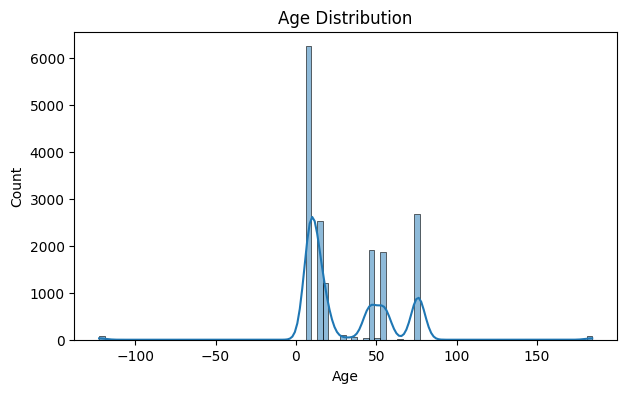

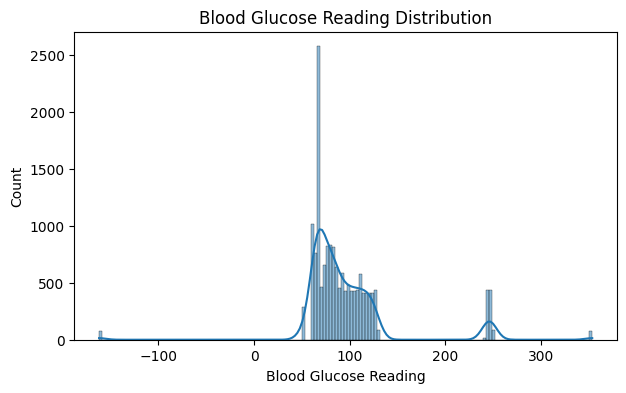

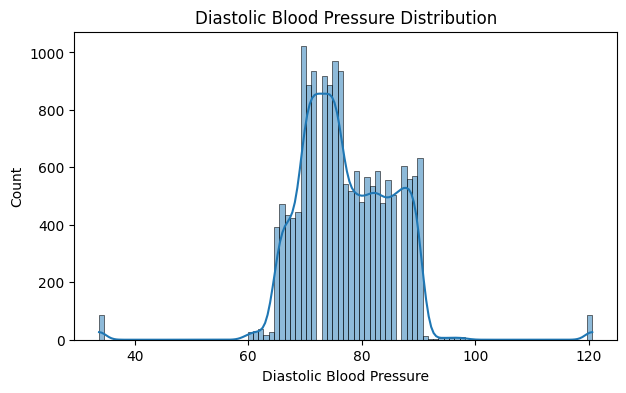

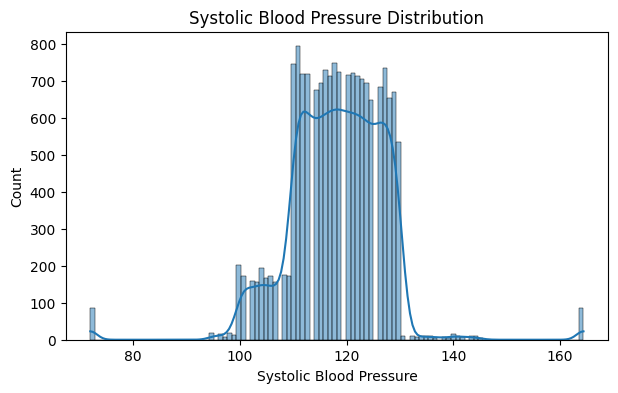

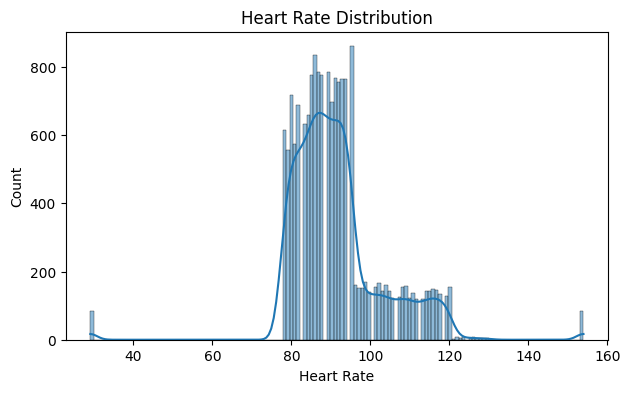

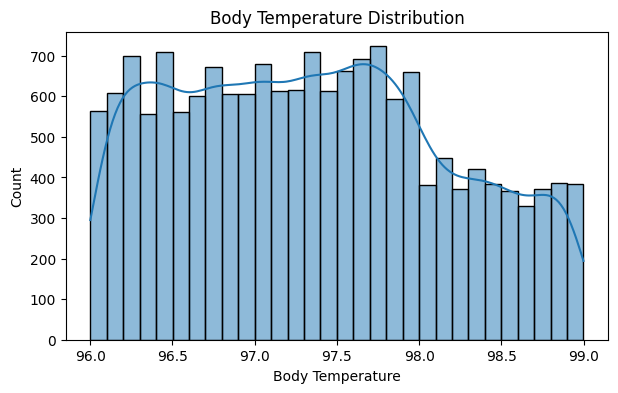

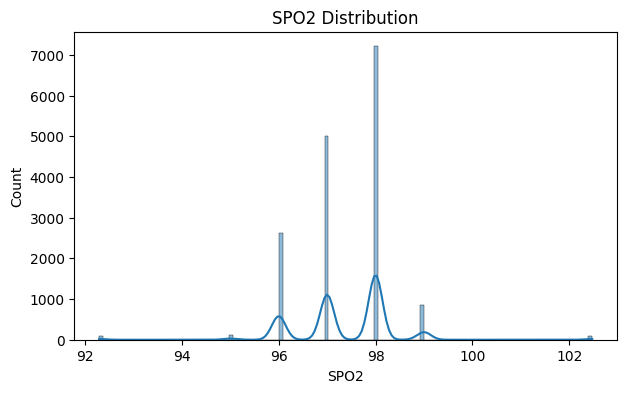

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in num_col:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

In [64]:
df_clean = df.copy()

df_clean = df_clean[
    (df_clean['Age'] >= 0) &
    (df_clean['Age'] <= 100)
]

df_clean = df_clean[
    df_clean['Blood Glucose Reading'] >= 0

]

df_clean = df_clean[
    df_clean['Sweating  (Y/N)'].isin([0, 1]) &
    df_clean['Shivering (Y/N)'].isin([0, 1])
].copy()

df_clean['Sweating  (Y/N)'] = df_clean['Sweating  (Y/N)'].astype(int)
df_clean['Shivering (Y/N)'] = df_clean['Shivering (Y/N)'].astype(int)


print("Before cleaning:")
print("Min SPO2:", df_clean['SPO2'].min())
print("Max SPO2:", df_clean['SPO2'].max())
print("Rows before:", df_clean.shape[0])

invalid_spo2 = df_clean[
    (df_clean['SPO2'] < 0) | 
    (df_clean['SPO2'] > 100)
]
print("Invalid SPO2 count:", invalid_spo2.shape[0])
invalid_spo2[['SPO2']].head()

df_clean = df_clean[
    (df_clean['SPO2'] >= 0) &
    (df_clean['SPO2'] <= 100)
].copy()


Before cleaning:
Min SPO2: 92.28743596975988
Max SPO2: 102.47628836495882
Rows before: 15421
Invalid SPO2 count: 75


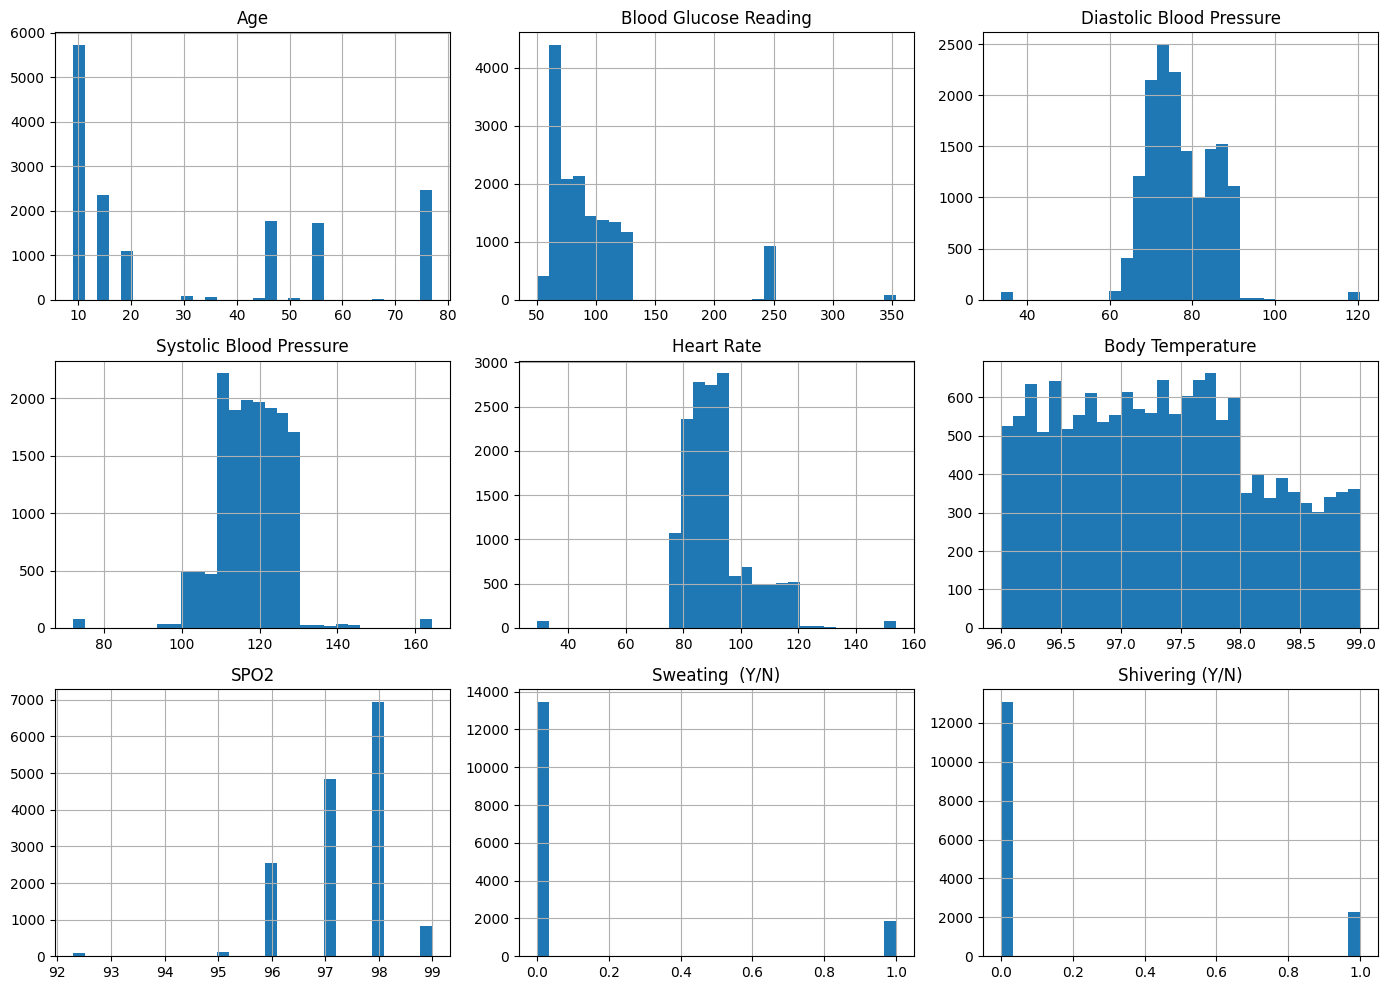

In [65]:
df_clean.hist(
    bins=30,
    figsize=(14, 10),
    grid=True
)

plt.tight_layout()
plt.show()

In [66]:
df_clean['Sweating  (Y/N)'].unique()

array([0, 1])

In [67]:
df_clean['Shivering (Y/N)'].unique()

array([0, 1])

In [68]:
df_clean.dtypes

Age                               float64
Gender                             object
Blood Glucose Reading             float64
Diastolic Blood Pressure          float64
Diastolic Blood Pressure Level     object
Systolic Blood Pressure           float64
Heart Rate                        float64
Body Temperature                  float64
SPO2                              float64
Sweating  (Y/N)                     int64
Shivering (Y/N)                     int64
Diabetic/NonDiabetic (D/N)         object
dtype: object

In [69]:
df_clean.head()

,Age,Gender,Blood Glucose Reading,Diastolic Blood Pressure,Diastolic Blood Pressure Level,Systolic Blood Pressure,Heart Rate,Body Temperature,SPO2,Sweating (Y/N),Shivering (Y/N),Diabetic/NonDiabetic (D/N)
0,9.0,M,79.0,73.0,High,118.0,98.0,98.300707,99.0,0,0,N
1,9.0,F,80.0,73.0,High,119.0,102.0,98.300707,94.0,1,0,N
2,9.0,M,70.0,76.0,High,110.0,81.0,98.300707,98.0,1,0,N
4,66.0,M,100.0,96.0,High,144.0,92.0,97.807052,98.0,0,0,N
5,66.0,NaN,100.0,72.0,Low,133.0,89.0,98.351676,96.0,0,0,N


<function matplotlib.pyplot.show(close=None, block=None)>

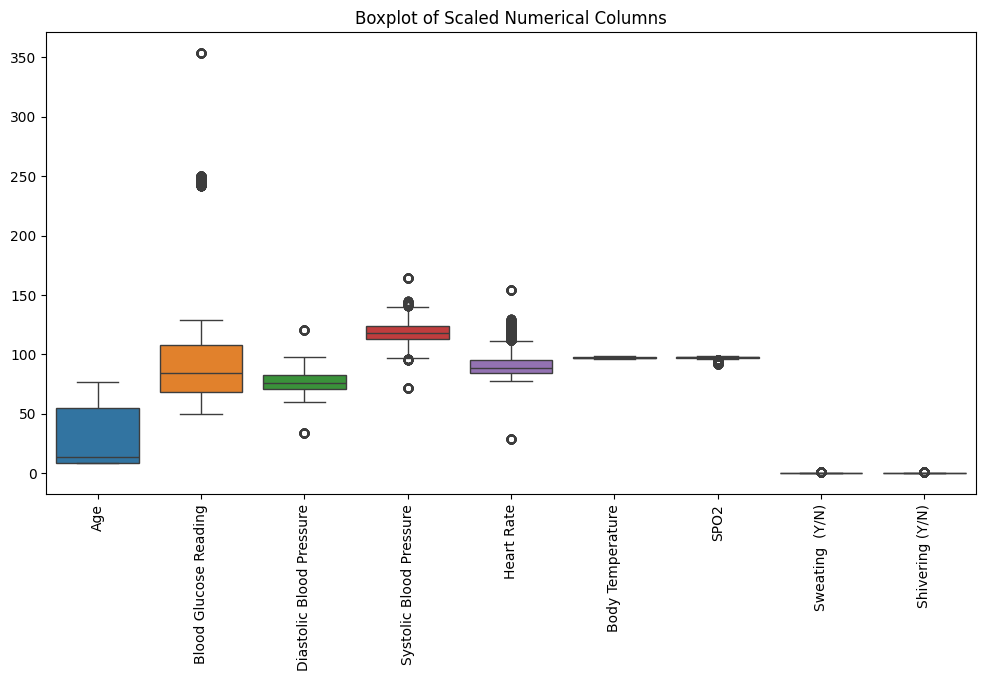

In [70]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_clean)
plt.title('Boxplot of Scaled Numerical Columns')
plt.xticks(rotation=90)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

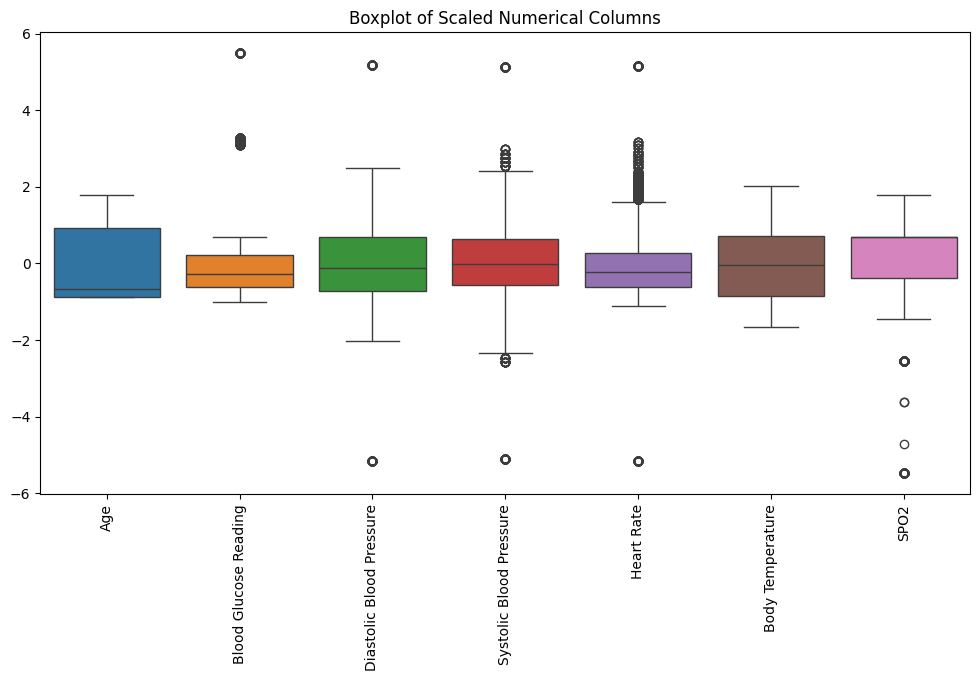

In [71]:
#boxplot 
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
scaled=scaler.fit_transform(df_clean[num_col])
df_clean_scaled=pd.DataFrame(scaled,columns=num_col)

plt.figure(figsize=(12,6))
sns.boxplot(data=df_clean_scaled)
plt.title('Boxplot of Scaled Numerical Columns')
plt.xticks(rotation=90)
plt.show

0 = average value
negative value = below average
positive value = above average

In [72]:
df_clean.describe()

,Age,Blood Glucose Reading,Diastolic Blood Pressure,Systolic Blood Pressure,Heart Rate,Body Temperature,SPO2,Sweating (Y/N),Shivering (Y/N)
count,15346.000000,15346.000000,15328.000000,15346.000000,15346.000000,15137.000000,15346.000000,15346.000000,15346.000000
mean,31.120683,97.159678,77.109877,118.158320,91.613288,97.359128,97.352367,0.122638,0.147335
std,25.589397,46.706995,8.406591,9.019447,12.118856,0.814552,0.924235,0.328032,0.354451
min,9.000000,50.000000,33.724424,71.984987,29.065509,96.000132,92.287436,0.000000,0.000000
25%,9.000000,68.000000,71.000000,113.000000,84.000000,96.674465,97.000000,0.000000,0.000000
50%,14.000000,84.000000,76.000000,118.000000,89.000000,97.331110,98.000000,0.000000,0.000000
75%,55.000000,108.000000,83.000000,124.000000,95.000000,97.951796,98.000000,0.000000,0.000000
max,77.000000,353.498975,120.622562,164.389343,153.982873,98.999792,99.000000,1.000000,1.000000


In [73]:
total_outliers = []

for col in num_col:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_clean[
        (df_clean[col] < lower_bound) |
        (df_clean[col] > upper_bound)
    ]

    total_outliers.append({
        'Feature': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower_Bound': lower_bound,
        'Upper_Bound': upper_bound,
        'Outlier_Count': outliers.shape[0]
    })

iqr_df = pd.DataFrame(total_outliers)

iqr_df

,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count
0,Age,9.000000,55.000000,46.000000,-60.000000,124.000000,0
1,Blood Glucose Reading,68.000000,108.000000,40.000000,8.000000,168.000000,1010
2,Diastolic Blood Pressure,71.000000,83.000000,12.000000,53.000000,101.000000,153
3,Systolic Blood Pressure,113.000000,124.000000,11.000000,96.500000,140.500000,230
4,Heart Rate,84.000000,95.000000,11.000000,67.500000,111.500000,1346
5,Body Temperature,96.674465,97.951796,1.277331,94.758469,99.867792,0
6,SPO2,97.000000,98.000000,1.000000,95.500000,99.500000,203


In [74]:
df_clean.describe()

,Age,Blood Glucose Reading,Diastolic Blood Pressure,Systolic Blood Pressure,Heart Rate,Body Temperature,SPO2,Sweating (Y/N),Shivering (Y/N)
count,15346.000000,15346.000000,15328.000000,15346.000000,15346.000000,15137.000000,15346.000000,15346.000000,15346.000000
mean,31.120683,97.159678,77.109877,118.158320,91.613288,97.359128,97.352367,0.122638,0.147335
std,25.589397,46.706995,8.406591,9.019447,12.118856,0.814552,0.924235,0.328032,0.354451
min,9.000000,50.000000,33.724424,71.984987,29.065509,96.000132,92.287436,0.000000,0.000000
25%,9.000000,68.000000,71.000000,113.000000,84.000000,96.674465,97.000000,0.000000,0.000000
50%,14.000000,84.000000,76.000000,118.000000,89.000000,97.331110,98.000000,0.000000,0.000000
75%,55.000000,108.000000,83.000000,124.000000,95.000000,97.951796,98.000000,0.000000,0.000000
max,77.000000,353.498975,120.622562,164.389343,153.982873,98.999792,99.000000,1.000000,1.000000


In [75]:
df_clean.head()

,Age,Gender,Blood Glucose Reading,Diastolic Blood Pressure,Diastolic Blood Pressure Level,Systolic Blood Pressure,Heart Rate,Body Temperature,SPO2,Sweating (Y/N),Shivering (Y/N),Diabetic/NonDiabetic (D/N)
0,9.0,M,79.0,73.0,High,118.0,98.0,98.300707,99.0,0,0,N
1,9.0,F,80.0,73.0,High,119.0,102.0,98.300707,94.0,1,0,N
2,9.0,M,70.0,76.0,High,110.0,81.0,98.300707,98.0,1,0,N
4,66.0,M,100.0,96.0,High,144.0,92.0,97.807052,98.0,0,0,N
5,66.0,NaN,100.0,72.0,Low,133.0,89.0,98.351676,96.0,0,0,N


In [76]:
df_clean.duplicated().sum()

np.int64(0)

In [77]:
df_clean.dtypes

Age                               float64
Gender                             object
Blood Glucose Reading             float64
Diastolic Blood Pressure          float64
Diastolic Blood Pressure Level     object
Systolic Blood Pressure           float64
Heart Rate                        float64
Body Temperature                  float64
SPO2                              float64
Sweating  (Y/N)                     int64
Shivering (Y/N)                     int64
Diabetic/NonDiabetic (D/N)         object
dtype: object

## Categorical features

In [91]:
target = 'Diabetic/NonDiabetic (D/N)'

cat_col = [
    'Gender',
    'Diastolic Blood Pressure Level'
]

binary_cols = [
    'Sweating  (Y/N)',
    'Shivering (Y/N)'
]

all_cat_col = cat_col + binary_cols

print("cat_col:", cat_col)
print("binary_cols:", binary_cols)
print("all_cat_col:", all_cat_col)

cat_col: ['Gender', 'Diastolic Blood Pressure Level']
binary_cols: ['Sweating  (Y/N)', 'Shivering (Y/N)']
all_cat_col: ['Gender', 'Diastolic Blood Pressure Level', 'Sweating  (Y/N)', 'Shivering (Y/N)']


In [92]:
df_clean.head()

,Age,Gender,Blood Glucose Reading,Diastolic Blood Pressure,Diastolic Blood Pressure Level,Systolic Blood Pressure,Heart Rate,Body Temperature,SPO2,Sweating (Y/N),Shivering (Y/N),Diabetic/NonDiabetic (D/N)
0,9.0,M,79.0,73.0,High,118.0,98.0,98.300707,99.0,0,0,NaN
1,9.0,F,80.0,73.0,High,119.0,102.0,98.300707,94.0,1,0,NaN
2,9.0,M,70.0,76.0,High,110.0,81.0,98.300707,98.0,1,0,NaN
4,66.0,M,100.0,96.0,High,144.0,92.0,97.807052,98.0,0,0,NaN
5,66.0,NaN,100.0,72.0,Low,133.0,89.0,98.351676,96.0,0,0,NaN


In [88]:
for col in all_cat_col:
    print(col)
    print(df_clean[col].value_counts())
    print(df_clean[col].value_counts(normalize=True) * 100)
    print("------------------")

Gender
Gender
M    10563
F     4701
Name: count, dtype: int64
Gender
M    69.202044
F    30.797956
Name: proportion, dtype: float64
------------------
Diastolic Blood Pressure Level
Diastolic Blood Pressure Level
High      15246
Low          81
Medium        1
Name: count, dtype: int64
Diastolic Blood Pressure Level
High      99.465031
Low        0.528445
Medium     0.006524
Name: proportion, dtype: float64
------------------
Diabetic/NonDiabetic (D/N)
Series([], Name: count, dtype: int64)
Series([], Name: proportion, dtype: float64)
------------------
Sweating  (Y/N)
Sweating  (Y/N)
0    13464
1     1882
Name: count, dtype: int64
Sweating  (Y/N)
0    87.736218
1    12.263782
Name: proportion, dtype: float64
------------------
Shivering (Y/N)
Shivering (Y/N)
0    13085
1     2261
Name: count, dtype: int64
Shivering (Y/N)
0    85.266519
1    14.733481
Name: proportion, dtype: float64
------------------


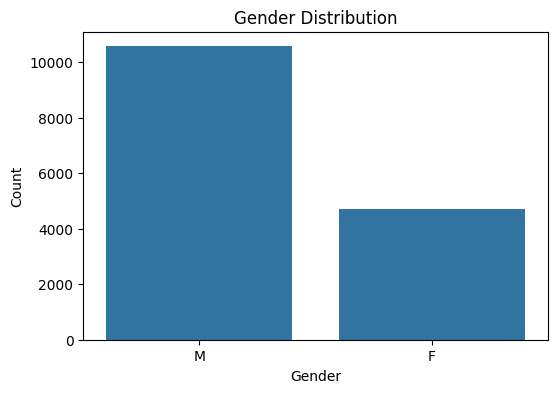

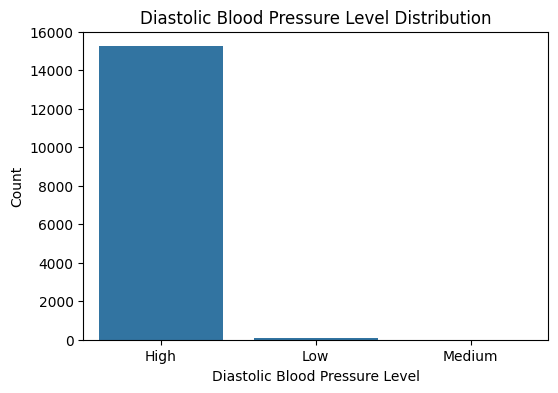

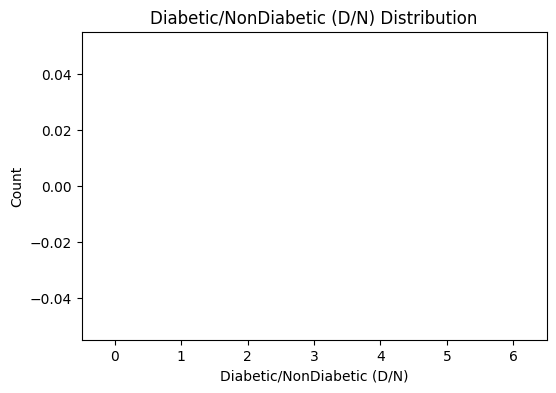

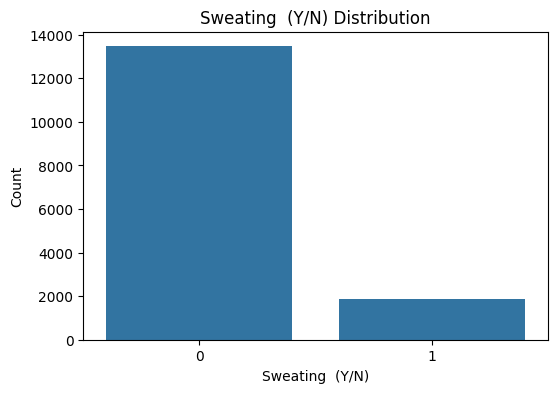

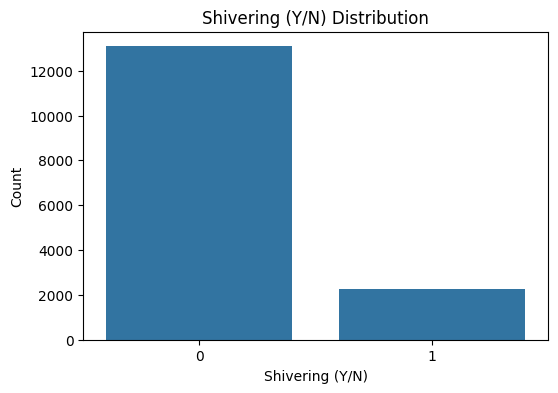

In [89]:

for col in all_cat_col:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, data=df_clean)
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

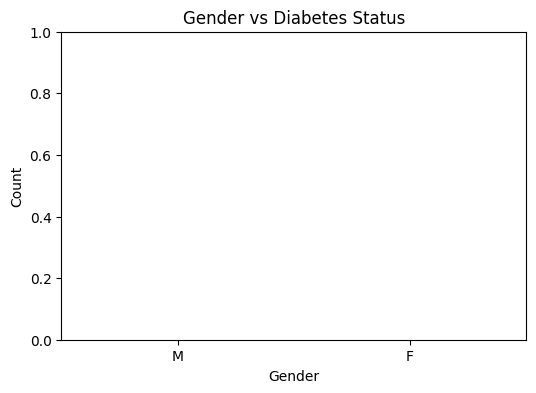

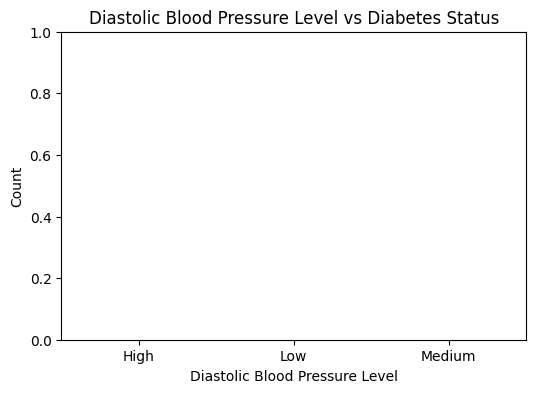

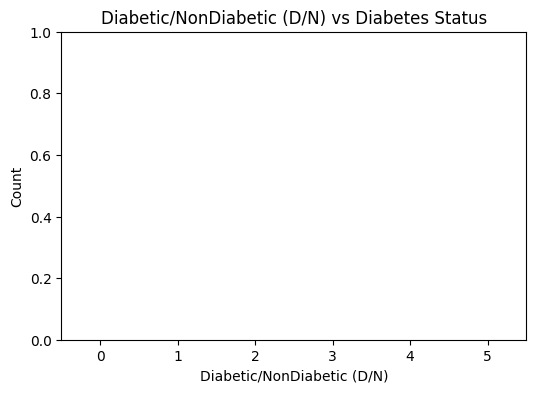

In [90]:
target = 'Diabetic/NonDiabetic (D/N)'

for col in cat_col:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, hue=target, data=df_clean)
    plt.title(f'{col} vs Diabetes Status')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()